In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from xgboost import XGBClassifier

In [11]:
df = pd.read_csv("../Data/processed/student_success_modeling_data.csv")

X = df.drop("success", axis=1)
y = df["success"]

print(X.shape)
print(y.shape)

(32593, 21)
(32593,)


In [12]:
# Clean column names for XGBoost

X.columns = (
    X.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace("%", "pct", regex=False)
    .str.replace("-", "_", regex=False)
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [14]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("XGBoost Results")
print("----------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

XGBoost Results
----------------
Accuracy:  0.7785
Precision: 0.7383
Recall:    0.8221
F1 Score:  0.7780
ROC-AUC:   0.8614


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78      5162
           1       0.74      0.82      0.78      4616

    accuracy                           0.78      9778
   macro avg       0.78      0.78      0.78      9778
weighted avg       0.78      0.78      0.78      9778



In [19]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
})

feature_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
2,total_clicks,0.344714
3,gender_M,0.119554
5,highest_education_Lower Than A Level,0.101132
1,studied_credits,0.059105
0,num_of_prev_attempts,0.043328
17,imd_band_Unknown,0.031989
20,disability_Y,0.031624
16,imd_band_90_100pct,0.027209
4,highest_education_HE Qualification,0.025308
8,imd_band_10_20,0.023504


In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        0.8264,
        0.8202,
        roc_auc
    ]
})

comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
2,XGBoost,0.86139
0,Logistic Regression,0.82640
1,Random Forest,0.82020


While Logistic Regression provided a strong baseline, XGBoost achieved the highest predictive performance with an ROC-AUC of 0.861, outperforming both Logistic Regression (0.826) and Random Forest (0.820).

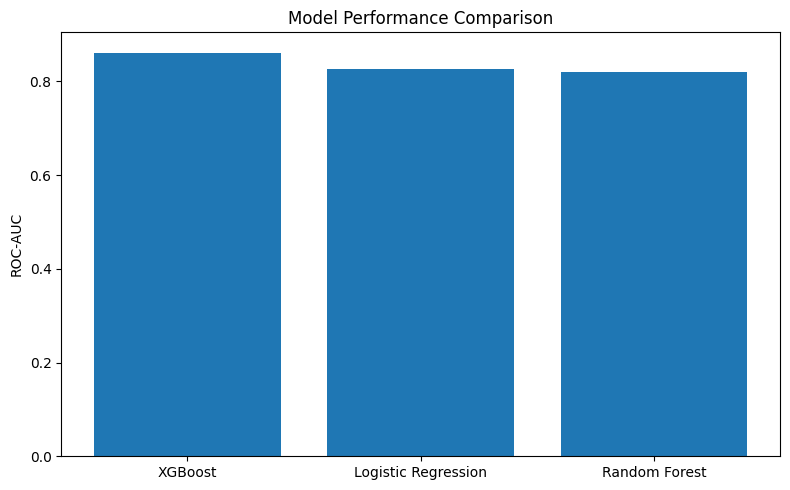

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        0.8264,
        0.8202,
        0.8614
    ]
})

comparison = comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC_AUC"]
)

plt.title("Model Performance Comparison")
plt.ylabel("ROC-AUC")

plt.tight_layout()

plt.savefig(
    "../Figures/model_comparison_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()